In [1]:
import pandas as pd
import yfinance as yf
import numpy as np

data = yf.download('BTC-USD', start='2020-01-01', end='2025-11-16')
data.index = pd.to_datetime(data.index)

fomc_df = pd.read_csv('FOMC_Dates_with_Rate_Changes.csv')
fomc_dates = pd.to_datetime(fomc_df['meeting_date_parsed'])

cpi_dates = pd.to_datetime([
    '2020-01-14', '2020-02-13', '2020-03-11', '2020-04-10', '2020-05-12', '2020-06-10', 
    '2020-07-14', '2020-08-12', '2020-09-11', '2020-10-13', '2020-11-12', '2020-12-10',
    '2021-01-13', '2021-02-10', '2021-03-10', '2021-04-13', '2021-05-12', '2021-06-10', 
    '2021-07-13', '2021-08-11', '2021-09-14', '2021-10-13', '2021-11-10', '2021-12-10',
    '2022-01-12', '2022-02-10', '2022-03-10', '2022-04-12', '2022-05-11', '2022-06-10', 
    '2022-07-13', '2022-08-10', '2022-09-13', '2022-10-13', '2022-11-10', '2022-12-13',
    '2023-01-12', '2023-02-14', '2023-03-14', '2023-04-12', '2023-05-10', '2023-06-13', 
    '2023-07-12', '2023-08-10', '2023-09-13', '2023-10-12', '2023-11-14', '2023-12-12',
    '2024-01-11', '2024-02-13', '2024-03-12', '2024-04-10', '2024-05-15', '2024-06-12', 
    '2024-07-11', '2024-08-14', '2024-09-11', '2024-10-10', '2024-11-13',
    '2025-01-15', '2025-02-12', '2025-03-12', '2025-04-10', '2025-05-13', '2025-06-11', 
    '2025-07-15', '2025-08-12', '2025-09-11', '2025-10-24', '2025-11-13'
])

data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
data['Volatility'] = data['Log_Return'].abs()

vol_threshold = data['Volatility'].quantile(0.75)
data['Is_High_Vol_Tomorrow'] = (data['Volatility'].shift(-1) > vol_threshold).astype(int)

data['Is_FOMC_Day'] = data.index.isin(fomc_dates).astype(int)
data['Is_CPI_Day'] = data.index.isin(cpi_dates).astype(int)
data['Volatility_Lag_1'] = data['Volatility'].shift(1)
data['Volatility_MA_7'] = data['Volatility'].rolling(window=7).mean()

model_data = data.dropna()
model_data.to_csv('project_model_data.csv')

print(f"Dataset created: {len(model_data)} rows")
print(f"High volatility threshold: {vol_threshold:.5f}")




C:\Users\alber\AppData\Local\Temp\ipykernel_39928\4012941988.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('BTC-USD', start='2020-01-01', end='2025-11-16')
[*********************100%***********************]  1 of 1 completed

Dataset created: 2139 rows
High volatility threshold: 0.02886


In [2]:
%pip install lightgbm seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\alber\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

model_data = pd.read_csv('project_model_data.csv', index_col=0, parse_dates=True)

train_data = model_data.loc['2020-01-08':'2024-12-31']
test_data = model_data.loc['2025-01-01':]

feature_cols = ['Is_FOMC_Day', 'Is_CPI_Day', 'Volatility_Lag_1', 'Volatility_MA_7']
target_col = 'Is_High_Vol_Tomorrow'

X_train = train_data[feature_cols]
y_train = train_data[target_col]
X_test = test_data[feature_cols]
y_test = test_data[target_col]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = {}

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
results['Logistic Regression'] = accuracy_score(y_test, y_pred_log)

svm_model = SVC(kernel='rbf', probability=True, random_state=42) 
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
results['SVM'] = accuracy_score(y_test, y_pred_svm)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, y_pred_rf)

print("Model Accuracy Results:")
for model_name, score in results.items():
    print(f"{model_name}: {score:.4f}")

print("\nLogistic Regression:")
print(classification_report(y_test, y_pred_log))

print("\nSVM:")
print(classification_report(y_test, y_pred_svm))

print("\nRandom Forest:")
print(classification_report(y_test, y_pred_rf))

C:\Users\alber\AppData\Local\Temp\ipykernel_39928\102491385.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  model_data = pd.read_csv('project_model_data.csv', index_col=0, parse_dates=True)


Model Accuracy Results:
Logistic Regression: 0.8401
SVM: 0.8401
Random Forest: 0.7806

Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.84      1.00      0.91       268
         1.0       0.00      0.00      0.00        51

    accuracy                           0.84       319
   macro avg       0.42      0.50      0.46       319
weighted avg       0.71      0.84      0.77       319


SVM:
              precision    recall  f1-score   support

         0.0       0.84      1.00      0.91       268
         1.0       0.00      0.00      0.00        51

    accuracy                           0.84       319
   macro avg       0.42      0.50      0.46       319
weighted avg       0.71      0.84      0.77       319


Random Forest:
              precision    recall  f1-score   support

         0.0       0.84      0.91      0.88       268
         1.0       0.15      0.08      0.10        51

    accuracy                           0.78       31

C:\Users\alber\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\alber\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\alber\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Feature Coefficients:
         Feature  Coefficient  Abs_Coefficient
 Volatility_MA_7     0.375436         0.375436
      Is_CPI_Day     0.047902         0.047902
     Is_FOMC_Day     0.042352         0.042352
Volatility_Lag_1    -0.011574         0.011574


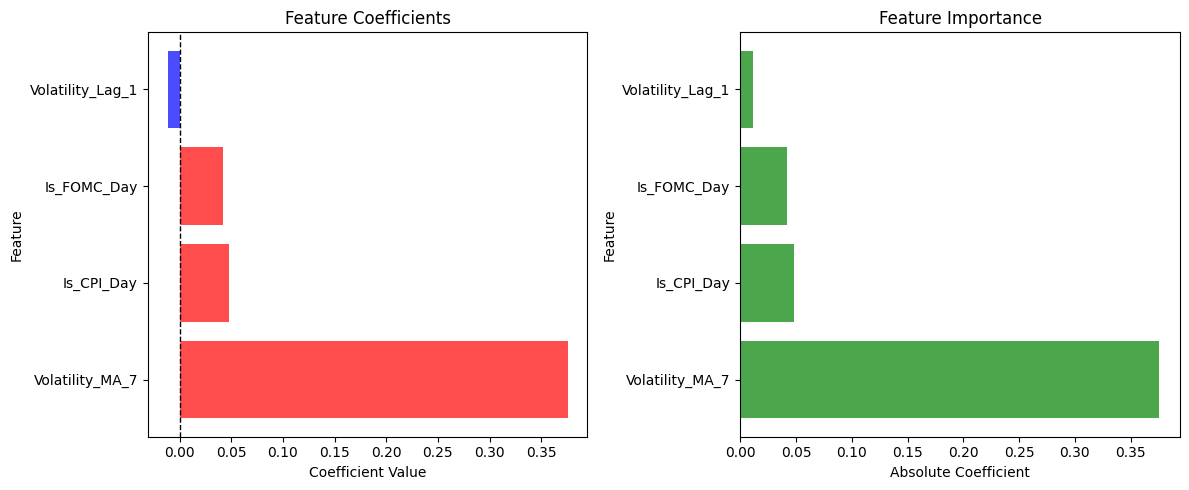

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

coefficients = log_model.coef_[0]
feature_names = X_train.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print("Feature Coefficients:")
print(coef_df.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colors = ['red' if c > 0 else 'blue' for c in coef_df['Coefficient']]
ax1.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('Coefficient Value')
ax1.set_ylabel('Feature')
ax1.set_title('Feature Coefficients')

ax2.barh(coef_df['Feature'], coef_df['Abs_Coefficient'], color='green', alpha=0.7)
ax2.set_xlabel('Absolute Coefficient')
ax2.set_ylabel('Feature')
ax2.set_title('Feature Importance')

plt.tight_layout()
plt.savefig('logistic_regression_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
